In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
# https://www.kaggle.com/datasets/tamber/steam-video-games
dataset = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/Recommendation_systems/steam-200k.csv',
    header=None,
    names=['user-id', 'game-title', 'behavior-name', 'value', 'timestamp'],
)
dataset

,user-id,game-title,behavior-name,value,timestamp
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
...,...,...,...,...,...
199995,128470551,Titan Souls,play,1.5,0
199996,128470551,Grand Theft Auto Vice City,purchase,1.0,0
199997,128470551,Grand Theft Auto Vice City,play,1.5,0
199998,128470551,RUSH,purchase,1.0,0


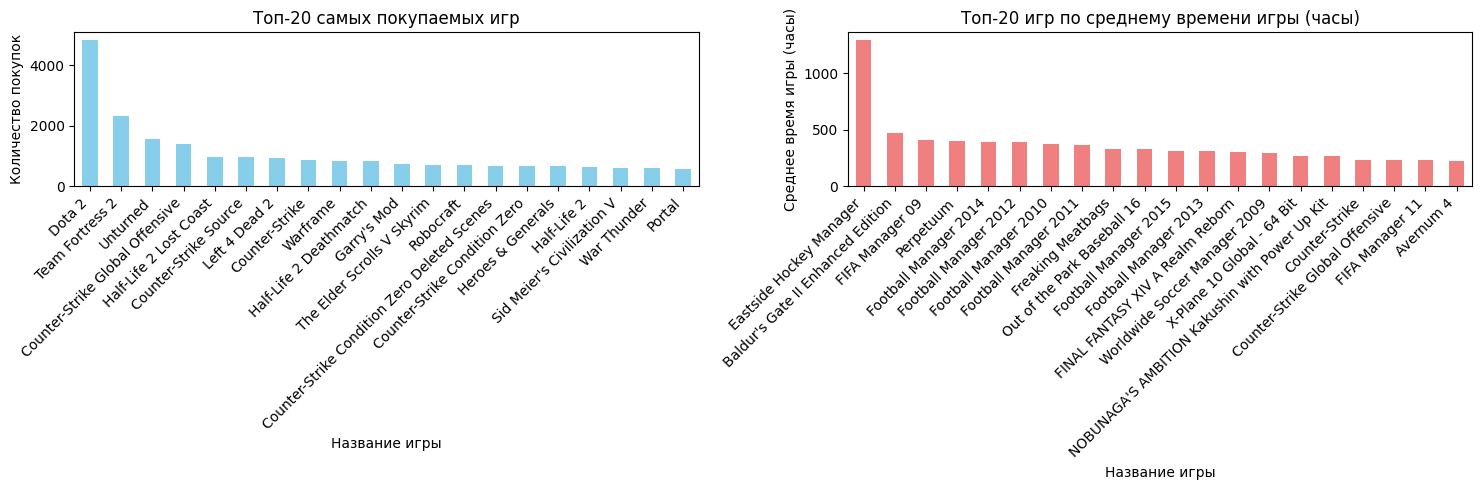

In [3]:
import matplotlib.pyplot as plt

# Анализ данных о играх и времени
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
purchase_counts = dataset[dataset['behavior-name'] == 'purchase'].groupby('game-title').size().sort_values(ascending=False)
purchase_counts.head(20).plot(kind='bar', color='skyblue')
plt.title('Топ-20 самых покупаемых игр')
plt.xlabel('Название игры')
plt.ylabel('Количество покупок')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
play_data = dataset[dataset['behavior-name'] == 'play']
play_time = play_data.groupby('game-title')['value'].mean().sort_values(ascending=False)
play_time.head(20).plot(kind='bar', color='lightcoral')
plt.title('Топ-20 игр по среднему времени игры (часы)')
plt.xlabel('Название игры')
plt.ylabel('Среднее время игры (часы)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [4]:
# Предварительная обработка данных
# Оставляем только записи с игровыми сессиями (play)
play_data = dataset[dataset['behavior-name'] == 'play'].copy()

# Создаем матрицу "пользователь-игра"
user_game_matrix = play_data.pivot_table(
    index='user-id',
    columns='game-title',
    values='value',
    aggfunc='sum',
    fill_value=0
)

print(f"Размер матрицы пользователь-игра: {user_game_matrix.shape}")

# Фильтруем пользователей с более чем 5 играми
user_play_counts = (user_game_matrix > 0).sum(axis=1)
active_users = user_play_counts[user_play_counts > 5].index
user_game_matrix = user_game_matrix.loc[active_users]

print(f"Размер матрицы после фильтрации: {user_game_matrix.shape}")

Размер матрицы пользователь-игра: (11350, 3600)
Размер матрицы после фильтрации: (2129, 3600)


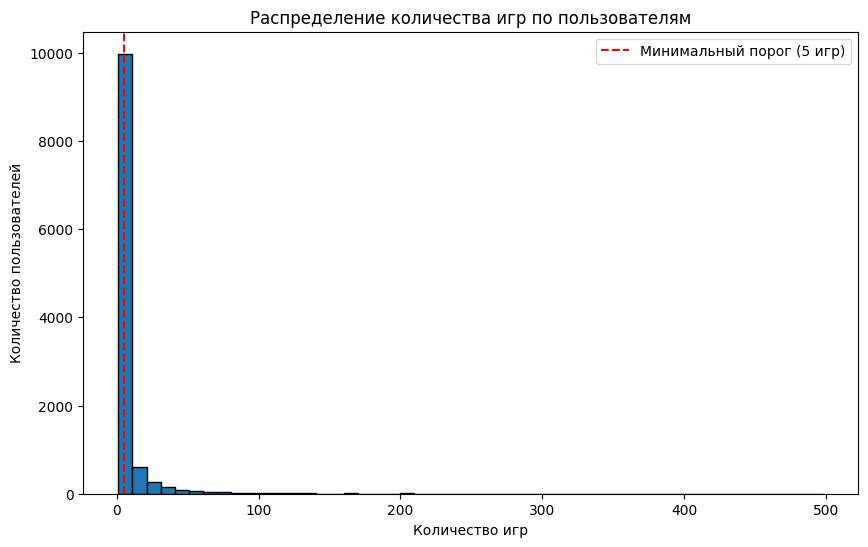

In [5]:
# Визуализация: распределение количества игр по пользователям
plt.figure(figsize=(10, 6))
plt.hist(user_play_counts[user_play_counts > 0], bins=50, edgecolor='black')
plt.title('Распределение количества игр по пользователям')
plt.xlabel('Количество игр')
plt.ylabel('Количество пользователей')
plt.axvline(x=5, color='red', linestyle='--', label='Минимальный порог (5 игр)')
plt.legend()
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.sparse import csr_matrix
from tqdm import tqdm
import seaborn as sns

In [7]:
# Исправленные функции для вычисления метрик схожести
def jaccard_similarity(vec1, vec2):
    """Расстояние Жаккарда между двумя векторами"""
    # Преобразуем в бинарные вектора (играл/не играл)
    vec1_binary = (vec1 > 0).astype(int)
    vec2_binary = (vec2 > 0).astype(int)

    set1 = set(np.where(vec1_binary)[0])
    set2 = set(np.where(vec2_binary)[0])

    if len(set1) == 0 or len(set2) == 0:
        return 0

    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))

    return intersection / union

def pearson_similarity(vec1, vec2):
    """Коэффициент корреляции Пирсона"""
    # Преобразуем в плотные массивы для вычислений
    vec1_dense = vec1.flatten()
    vec2_dense = vec2.flatten()

    # Находим общие игры (где оба пользователя играли)
    common_mask = (vec1_dense > 0) & (vec2_dense > 0)

    if np.sum(common_mask) < 2:
        return 0

    vec1_common = vec1_dense[common_mask]
    vec2_common = vec2_dense[common_mask]

    if np.std(vec1_common) == 0 or np.std(vec2_common) == 0:
        return 0

    return np.corrcoef(vec1_common, vec2_common)[0, 1]

def cosine_similarity(vec1, vec2):
    """Косинусное сходство"""
    # Преобразуем в плотные массивы
    vec1_dense = vec1.flatten()
    vec2_dense = vec2.flatten()

    dot_product = np.dot(vec1_dense, vec2_dense)
    norm1 = np.linalg.norm(vec1_dense)
    norm2 = np.linalg.norm(vec2_dense)

    if norm1 == 0 or norm2 == 0:
        return 0

    return dot_product / (norm1 * norm2)

In [8]:
# Обновленная функция для поиска похожих пользователей с прогресс-баром
def find_similar_users(user_idx, similarity_func, k=10):
    """Находит k наиболее похожих пользователей"""
    user_vector = sparse_user_game[user_idx]
    similarities = []

    for other_idx in tqdm(range(sparse_user_game.shape[0]), desc=f"Поиск похожих для пользователя {user_idx}"):
        if other_idx == user_idx:
            continue

        other_vector = sparse_user_game[other_idx]
        similarity = similarity_func(user_vector.toarray(), other_vector.toarray())
        similarities.append((other_idx, similarity))

    # Сортируем по убыванию схожести и берем топ-k
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:k]

# Преобразуем в разреженную матрицу для эффективности
sparse_user_game = csr_matrix(user_game_matrix.values)
user_ids = user_game_matrix.index
game_titles = user_game_matrix.columns

# Преобразуем в плотные массивы для теста
test_vec1 = sparse_user_game[0].toarray()
test_vec2 = sparse_user_game[1].toarray()

print(f"Jaccard similarity: {jaccard_similarity(test_vec1, test_vec2):.4f}")
print(f"Pearson similarity: {pearson_similarity(test_vec1, test_vec2):.4f}")
print(f"Cosine similarity: {cosine_similarity(test_vec1, test_vec2):.4f}")

Jaccard similarity: 1.0000
Pearson similarity: 1.0000
Cosine similarity: 0.0025


In [9]:
# Функция для предсказания рейтингов
def predict_ratings(user_idx, similar_users, games_to_predict):
    """Предсказывает рейтинги для указанных игр"""
    user_similarities = dict(similar_users)
    predictions = []

    for game_idx in games_to_predict:
        numerator = 0
        denominator = 0

        for similar_user_idx, similarity in similar_users:
            similar_user_rating = sparse_user_game[similar_user_idx, game_idx]
            if similar_user_rating > 0:
                numerator += similarity * similar_user_rating
                denominator += abs(similarity) # TODO ?

        if denominator > 0:
            predicted_rating = numerator / denominator
        else:
            predicted_rating = 0

        predictions.append(predicted_rating)

    return predictions

In [10]:
# Функция для оценки ROC-AUC
def evaluate_roc_auc(user_idx, similarity_func, k, test_ratio=0.3):
    """Оценивает ROC-AUC для конкретного пользователя"""
    user_ratings = sparse_user_game[user_idx].toarray().flatten()
    played_games = np.where(user_ratings > 0)[0]

    if len(played_games) < 2:
        return None

    # Разделяем на train/test
    np.random.shuffle(played_games)
    split_idx = int(len(played_games) * (1 - test_ratio))
    train_games = played_games[:split_idx]
    test_games = played_games[split_idx:]

    if len(test_games) == 0:
        return None

    # Находим похожих пользователей на основе train игр
    temp_user_vector = np.zeros_like(user_ratings)
    temp_user_vector[train_games] = user_ratings[train_games]

    # Временно заменяем вектор пользователя для вычисления схожести
    original_vector = sparse_user_game[user_idx].copy()
    sparse_user_game[user_idx] = csr_matrix(temp_user_vector)

    similar_users = find_similar_users(user_idx, similarity_func, k)

    # Восстанавливаем оригинальный вектор
    sparse_user_game[user_idx] = original_vector

    # Предсказываем для всех игр
    all_games = np.arange(len(user_ratings))
    predictions = predict_ratings(user_idx, similar_users, all_games)

    # Готовим данные для ROC-AUC
    true_labels = (user_ratings > 0).astype(int)
    predicted_scores = np.array(predictions)

    # Фильтруем игры, которые были в train (чтобы не учитывать их в оценке)
    mask = np.ones(len(true_labels), dtype=bool)
    mask[train_games] = False

    if np.sum(true_labels[mask]) == 0 or np.sum(true_labels[mask]) == np.sum(mask):
        return None

    try:
        roc_auc = roc_auc_score(true_labels[mask], predicted_scores[mask])
        return roc_auc
    except:
        return None

Обрабатываю метрику: Jaccard для пользователя 0


Поиск похожих для пользователя 0: 100%|██████████| 2129/2129 [00:00<00:00, 4618.97it/s]


Обрабатываю метрику: Pearson для пользователя 0


Поиск похожих для пользователя 0: 100%|██████████| 2129/2129 [00:00<00:00, 5276.55it/s]


Обрабатываю метрику: Cosine для пользователя 0


Поиск похожих для пользователя 0: 100%|██████████| 2129/2129 [00:00<00:00, 9689.31it/s]


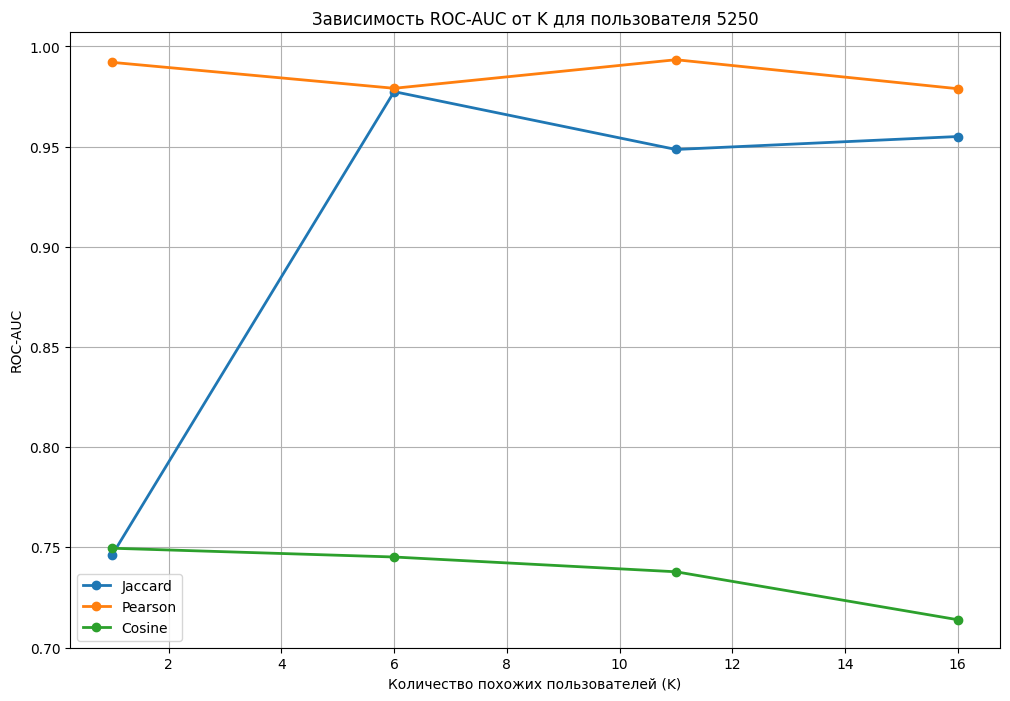

Обрабатываю метрику: Jaccard для пользователя 1


Поиск похожих для пользователя 1: 100%|██████████| 2129/2129 [00:00<00:00, 6447.65it/s]


Обрабатываю метрику: Pearson для пользователя 1


Поиск похожих для пользователя 1: 100%|██████████| 2129/2129 [00:00<00:00, 4771.93it/s]


Обрабатываю метрику: Cosine для пользователя 1


Поиск похожих для пользователя 1: 100%|██████████| 2129/2129 [00:00<00:00, 10724.47it/s]


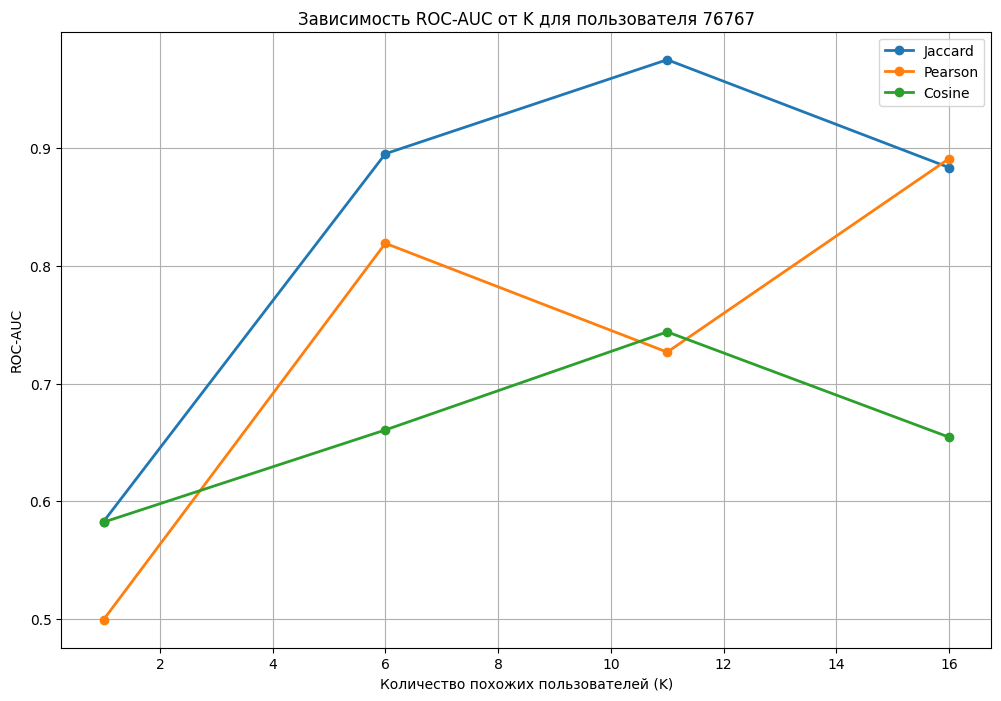

Обрабатываю метрику: Jaccard для пользователя 2


Поиск похожих для пользователя 2: 100%|██████████| 2129/2129 [00:00<00:00, 6428.13it/s]


Обрабатываю метрику: Pearson для пользователя 2


Поиск похожих для пользователя 2: 100%|██████████| 2129/2129 [00:00<00:00, 4614.46it/s]


Обрабатываю метрику: Cosine для пользователя 2


Поиск похожих для пользователя 2: 100%|██████████| 2129/2129 [00:00<00:00, 10825.41it/s]


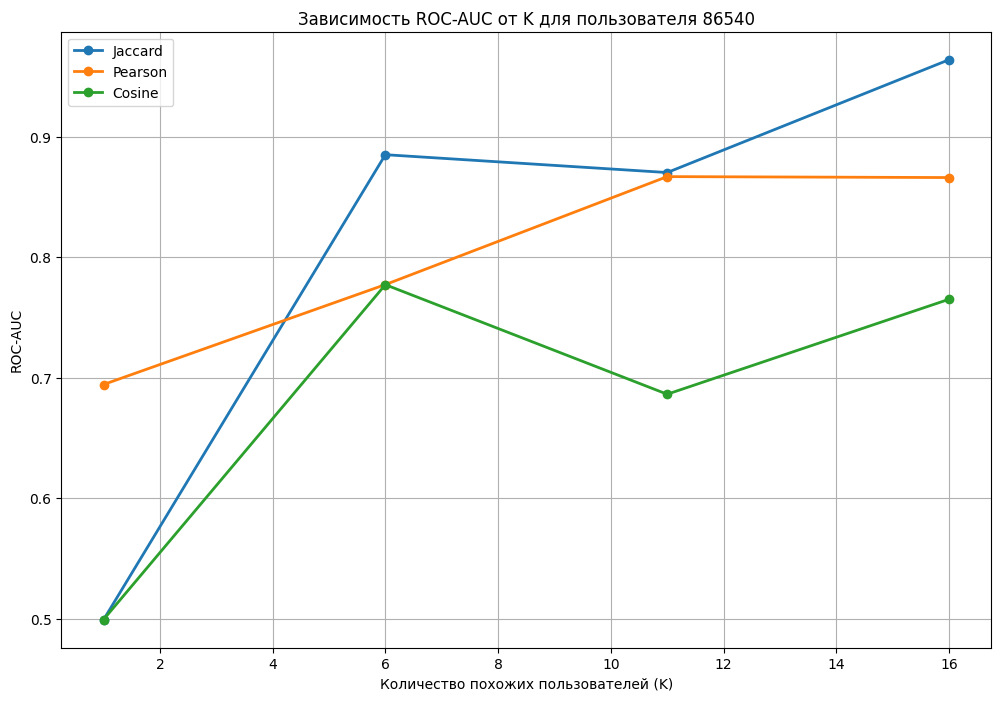

In [11]:
# Обновленная функция для сравнения метрик с исправлениями
def plot_similarity_comparison(user_idx, max_k):
    """Сравнивает разные метрики схожести для одного пользователя"""
    k_values = range(1, max_k + 1, 3)
    metrics = {
        'Jaccard': jaccard_similarity,
        'Pearson': pearson_similarity,
        'Cosine': cosine_similarity
    }

    plt.figure(figsize=(12, 8))

    for metric_name, similarity_func in metrics.items():
        print(f"Обрабатываю метрику: {metric_name} для пользователя {user_idx}")
        auc_scores = []

        for k in k_values:
            auc = evaluate_roc_auc(user_idx, similarity_func, k)
            if auc is not None:
                auc_scores.append(auc)
            else:
                auc_scores.append(0)

        plt.plot(k_values, auc_scores, marker='o', label=metric_name, linewidth=2)

    plt.xlabel('Количество похожих пользователей (K)')
    plt.ylabel('ROC-AUC')
    plt.title(f'Зависимость ROC-AUC от K для пользователя {user_ids[user_idx]}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Тестируем на нескольких пользователях с исправленными функциями
for i in range(3):
    plot_similarity_comparison(i, max_k=25)

Запускаем масштабное исследование с исправленными функциями:
Обрабатываю метрику: Jaccard
  K=1: 

Поиск похожих для пользователя 28: 100%|██████████| 2129/2129 [00:00<00:00, 6121.73it/s]


средний ROC-AUC = 0.527
  K=2: 

Поиск похожих для пользователя 28: 100%|██████████| 2129/2129 [00:00<00:00, 6168.43it/s]


средний ROC-AUC = 0.608
  K=3: 

...

средний ROC-AUC = 0.783
  K=24: 

Поиск похожих для пользователя 28: 100%|██████████| 2129/2129 [00:00<00:00, 9055.06it/s]


средний ROC-AUC = 0.791
  K=25: 

Поиск похожих для пользователя 28: 100%|██████████| 2129/2129 [00:00<00:00, 9010.14it/s]


средний ROC-AUC = 0.801


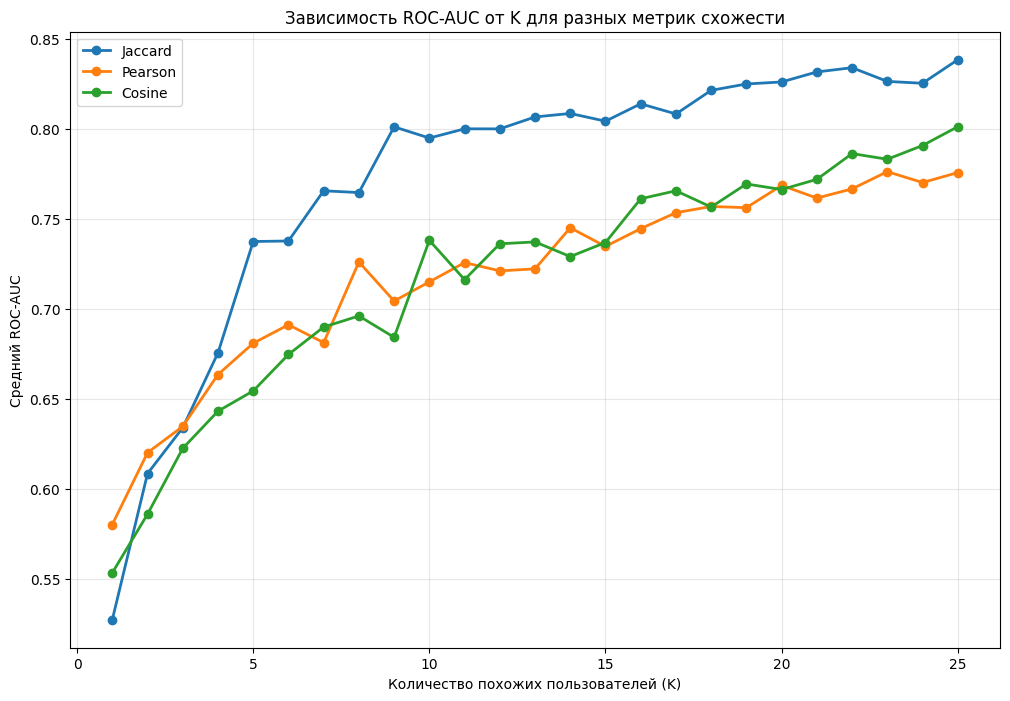

In [ ]:
# Обновленная функция для масштабного исследования с исправлениями
def large_scale_roc_auc_study(n_users, max_k):
    """Проводит масштабное исследование ROC-AUC для разных K и метрик"""
    k_values = range(1, max_k + 1)
    metrics = {
        'Jaccard': jaccard_similarity,
        'Pearson': pearson_similarity,
        'Cosine': cosine_similarity
    }

    results = {metric: [] for metric in metrics}

    # Выбираем случайных пользователей для исследования
    sampled_users = np.random.choice(
        range(min(n_users, sparse_user_game.shape[0])),
        size=min(n_users, sparse_user_game.shape[0]),
        replace=False
    )

    for metric_name, similarity_func in metrics.items():
        print(f"Обрабатываю метрику: {metric_name}")

        for k in k_values:
            print(f"  K={k}", end=": ")
            k_scores = []

            for user_idx in sampled_users:
                auc = evaluate_roc_auc(user_idx, similarity_func, k)
                if auc is not None:
                    k_scores.append(auc)

            avg_auc = np.mean(k_scores) if k_scores else 0
            results[metric_name].append(avg_auc)
            print(f"средний ROC-AUC = {avg_auc:.3f}")

    # Визуализация результатов
    plt.figure(figsize=(12, 8))
    for metric_name, scores in results.items():
        plt.plot(k_values, scores, marker='o', label=metric_name, linewidth=2)

    plt.xlabel('Количество похожих пользователей (K)')
    plt.ylabel('Средний ROC-AUC')
    plt.title('Зависимость ROC-AUC от K для разных метрик схожести')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return results, k_values

# Запускаем исправленное исследование
print("Запускаем масштабное исследование с исправленными функциями:")
results, k_values = large_scale_roc_auc_study(n_users=100, max_k=25)

In [ ]:
# Оптимизированная версия для ускорения вычислений
def optimized_find_similar_users(user_idx, similarity_func, k=10):
    """Оптимизированная версия поиска похожих пользователей"""
    user_vector = sparse_user_game[user_idx].toarray().flatten()
    user_played = set(np.where(user_vector > 0)[0])
    similarities = []

    # Предварительно вычисляем ненулевые элементы для всех пользователей
    for other_idx in range(sparse_user_game.shape[0]):
        if other_idx == user_idx:
            continue

        other_vector = sparse_user_game[other_idx].toarray().flatten()

        # Для Jaccard используем оптимизацию с множествами
        if similarity_func.__name__ == 'jaccard_similarity':
            other_played = set(np.where(other_vector > 0)[0])
            intersection = len(user_played.intersection(other_played))
            union = len(user_played.union(other_played))
            similarity = intersection / union if union > 0 else 0
        else:
            similarity = similarity_func(user_vector.reshape(1, -1), other_vector.reshape(1, -1))

        similarities.append((other_idx, similarity))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:k]

# Заменяем функцию в evaluate_roc_auc
def evaluate_roc_auc_optimized(user_idx, similarity_func, k, test_ratio=0.2):
    """Оптимизированная версия оценки ROC-AUC"""
    user_ratings = sparse_user_game[user_idx].toarray().flatten()
    played_games = np.where(user_ratings > 0)[0]

    if len(played_games) < 2:
        return None

    # Разделяем на train/test
    np.random.shuffle(played_games)
    split_idx = int(len(played_games) * (1 - test_ratio))
    train_games = played_games[:split_idx]
    test_games = played_games[split_idx:]

    if len(test_games) == 0:
        return None

    # Создаем временный вектор пользователя только с train играми
    temp_user_vector = np.zeros_like(user_ratings)
    temp_user_vector[train_games] = user_ratings[train_games]

    # Находим похожих пользователей на основе train игр
    similar_users = optimized_find_similar_users(user_idx,
                                               lambda x, y: similarity_func(x, y),
                                               k)

    # Предсказываем для всех игр
    all_games = np.arange(len(user_ratings))
    predictions = predict_ratings(user_idx, similar_users, all_games)

    # Готовим данные для ROC-AUC
    true_labels = (user_ratings > 0).astype(int)
    predicted_scores = np.array(predictions)

    # Фильтруем игры, которые были в train
    mask = np.ones(len(true_labels), dtype=bool)
    mask[train_games] = False

    if np.sum(true_labels[mask]) == 0 or np.sum(true_labels[mask]) == np.sum(mask):
        return None

    try:
        roc_auc = roc_auc_score(true_labels[mask], predicted_scores[mask])
        return roc_auc
    except:
        return None

In [ ]:
# Финальный тест с оптимизированными функциями
print("Финальный тест с оптимизированными функциями:")

# Тестируем на меньшем наборе данных для скорости
test_results = {}

for metric_name, similarity_func in [('Jaccard', jaccard_similarity),
                                     ('Pearson', pearson_similarity),
                                     ('Cosine', cosine_similarity)]:
    print(f"Тестируем {metric_name}...")
    auc_scores = []

    for k in [5, 10, 15]:
        auc = evaluate_roc_auc_optimized(0, similarity_func, k)
        auc_scores.append(auc if auc is not None else 0)
        print(f"  K={k}: ROC-AUC = {auc_scores[-1]:.3f}")

    test_results[metric_name] = auc_scores

print("\nРезультаты тестирования:")
for metric, scores in test_results.items():
    print(f"{metric}: {scores}")

Финальный тест с оптимизированными функциями:
Тестируем Jaccard...
  K=5: ROC-AUC = 0.963
  K=10: ROC-AUC = 0.987
  K=15: ROC-AUC = 0.987
Тестируем Pearson...
  K=5: ROC-AUC = 0.995
  K=10: ROC-AUC = 0.990
  K=15: ROC-AUC = 0.960
Тестируем Cosine...
  K=5: ROC-AUC = 0.746
  K=10: ROC-AUC = 0.743
  K=15: ROC-AUC = 0.733

Результаты тестирования:
Jaccard: [np.float64(0.9625765164162493), np.float64(0.9868530884808013), np.float64(0.987409571508069)]
Pearson: [np.float64(0.994991652754591), np.float64(0.9897050639955481), np.float64(0.9597245409015025)]
Cosine: [np.float64(0.7458263772954924), np.float64(0.7432526432943796), np.float64(0.7330968280467445)]


Лучшая метрика: Jaccard
Лучшее K: 9
Лучший ROC-AUC: 0.801


100%|██████████| 100/100 [01:47<00:00,  1.07s/it]


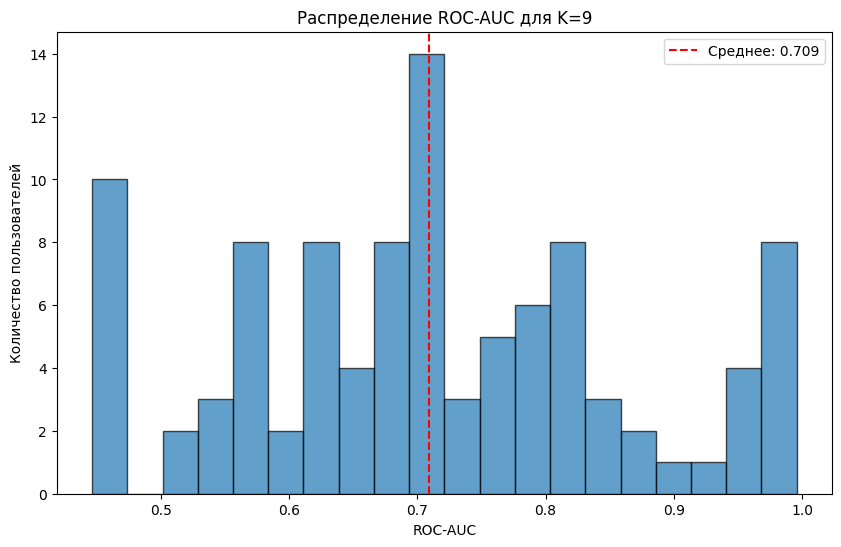

Средний ROC-AUC: 0.709
Медианный ROC-AUC: 0.706
Стандартное отклонение: 0.150


In [ ]:
# Дополнительная визуализация: распределение ROC-AUC для лучшей метрики
def plot_best_metric_distribution(best_metric_func, k_best, n_users=100):
    """Визуализирует распределение ROC-AUC для лучшей метрики"""
    sampled_users = np.random.choice(
        range(sparse_user_game.shape[0]),
        size=min(n_users, sparse_user_game.shape[0]),
        replace=False
    )

    auc_scores = []

    for user_idx in tqdm(sampled_users):
        auc = evaluate_roc_auc(user_idx, best_metric_func, k_best)
        if auc is not None:
            auc_scores.append(auc)

    plt.figure(figsize=(10, 6))
    plt.hist(auc_scores, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel('ROC-AUC')
    plt.ylabel('Количество пользователей')
    plt.title(f'Распределение ROC-AUC для K={k_best}')
    plt.axvline(x=np.mean(auc_scores), color='red', linestyle='--',
                label=f'Среднее: {np.mean(auc_scores):.3f}')
    plt.legend()
    plt.show()

    print(f"Средний ROC-AUC: {np.mean(auc_scores):.3f}")
    print(f"Медианный ROC-AUC: {np.median(auc_scores):.3f}")
    print(f"Стандартное отклонение: {np.std(auc_scores):.3f}")

# Определяем лучшую метрику на основе предыдущего исследования
best_metric = max(results, key=lambda x: np.max(results[x]))
best_k_index = np.argmax(results[best_metric])
best_k = list(k_values)[best_k_index]

print(f"Лучшая метрика: {best_metric}")
print(f"Лучшее K: {best_k}")
print(f"Лучший ROC-AUC: {results[best_metric][best_k_index]:.3f}")

metrics_dict = {
    'Jaccard': jaccard_similarity,
    'Pearson': pearson_similarity,
    'Cosine': cosine_similarity
}

plot_best_metric_distribution(metrics_dict[best_metric], best_k)

In [ ]:
# Функция для генерации рекомендаций
def generate_recommendations(user_id, similarity_func, k, n_recommendations=10):
    """Генерирует рекомендации для конкретного пользователя"""
    if user_id not in user_ids:
        return []

    user_idx = np.where(user_ids == user_id)[0][0]
    user_ratings = sparse_user_game[user_idx].toarray().flatten()

    # Игры, в которые пользователь уже играл
    played_games = np.where(user_ratings > 0)[0]

    # Находим похожих пользователей
    similar_users = find_similar_users(user_idx, similarity_func, k)

    # Предсказываем рейтинги для всех игр
    all_games = np.arange(len(user_ratings))
    predictions = predict_ratings(user_idx, similar_users, all_games)

    # Исключаем игры, в которые пользователь уже играл
    for game_idx in played_games:
        predictions[game_idx] = -1

    # Выбираем топ-N рекомендаций
    recommended_indices = np.argsort(predictions)[::-1][:n_recommendations]
    recommendations = []

    for idx in recommended_indices:
        if predictions[idx] > 0:
            recommendations.append({
                'game': game_titles[idx],
                'predicted_rating': predictions[idx]
            })

    return recommendations

# Пример использования
test_user = user_ids[0]
recommendations = generate_recommendations(test_user, metrics_dict[best_metric], best_k)

print(f"Рекомендации для пользователя {test_user}:")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec['game']} (предсказанный рейтинг: {rec['predicted_rating']:.2f})")